In [4]:
# Game from Claude
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
import pickle
import itertools

class TicTacToeGame:
    """Simple tic-tac-toe game logic"""
    
    def __init__(self):
        self.board = np.zeros(9, dtype=int)
    
    def reset(self):
        self.board = np.zeros(9, dtype=int)
    
    def make_move(self, position, player):
        """Make a move. Player 1 or -1"""
        if self.board[position] == 0:
            self.board[position] = player
            return True
        return False
    
    def get_winner(self):
        """Check if there's a winner. Returns 1, -1, or 0"""
        b = self.board.reshape(3, 3)
        
        # Check rows, columns, diagonals
        for i in range(3):
            if abs(b[i, :].sum()) == 3:
                return int(np.sign(b[i, :].sum()))
            if abs(b[:, i].sum()) == 3:
                return int(np.sign(b[:, i].sum()))
        
        if abs(b.diagonal().sum()) == 3:
            return int(np.sign(b.diagonal().sum()))
        if abs(np.fliplr(b).diagonal().sum()) == 3:
            return int(np.sign(np.fliplr(b).diagonal().sum()))
        
        return 0
    
    def is_full(self):
        return np.all(self.board != 0)
    
    def get_valid_moves(self):
        return np.where(self.board == 0)[0]
    
    def copy(self):
        new_game = TicTacToeGame()
        new_game.board = self.board.copy()
        return new_game


def minimax(game, player, alpha=-np.inf, beta=np.inf):
    """Minimax algorithm with alpha-beta pruning to find optimal moves"""
    winner = game.get_winner()
    
    # Terminal states
    if winner == 1:
        return 1, None
    elif winner == -1:
        return -1, None
    elif game.is_full():
        return 0, None
    
    valid_moves = game.get_valid_moves()
    best_move = valid_moves[0]
    
    if player == 1:  # Maximizing player
        best_value = -np.inf
        for move in valid_moves:
            game_copy = game.copy()
            game_copy.make_move(move, player)
            value, _ = minimax(game_copy, -player, alpha, beta)
            
            if value > best_value:
                best_value = value
                best_move = move
            
            alpha = max(alpha, value)
            if beta <= alpha:
                break
        
        return best_value, best_move
    else:  # Minimizing player
        best_value = np.inf
        for move in valid_moves:
            game_copy = game.copy()
            game_copy.make_move(move, player)
            value, _ = minimax(game_copy, -player, alpha, beta)
            
            if value < best_value:
                best_value = value
                best_move = move
            
            beta = min(beta, value)
            if beta <= alpha:
                break
        
        return best_value, best_move


def generate_training_data(num_games=5000):
    """Generate training data using minimax optimal play"""
    X = []  # Board states
    y = []  # Optimal moves
    
    print(f"Generating {num_games} training examples...")
    
    for i in range(num_games):
        if i % 10 == 0:
            print(f"Generated {i} examples...")
        
        game = TicTacToeGame()
        current_player = 1
        
        # Play random moves for variety in training data
        num_random_moves = np.random.randint(0, 3)
        
        for _ in range(num_random_moves):
            if game.get_winner() != 0 or game.is_full():
                break
            
            valid_moves = game.get_valid_moves()
            move = np.random.choice(valid_moves)
            game.make_move(move, current_player)
            current_player = -current_player
        
        # Now play optimally and record the data
        while game.get_winner() == 0 and not game.is_full():
            _, best_move = minimax(game, current_player)
            
            # Record the state and optimal move
            X.append(game.board.copy())
            y.append(best_move)
            
            game.make_move(best_move, current_player)
            current_player = -current_player
    
    print(f"Generated {len(X)} training examples total")
    return np.array(X), np.array(y)


def train_mlp(X, y):
    """Train the MLP classifier"""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    print("\nTraining MLP...")
    mlp = MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42,
        verbose=True
    )
    
    mlp.fit(X_train, y_train)
    
    train_accuracy = mlp.score(X_train, y_train)
    test_accuracy = mlp.score(X_test, y_test)
    
    print(f"\nTraining Accuracy: {train_accuracy:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    
    return mlp, X_train, X_test, y_train, y_test


def play_game_mlp_vs_optimal(mlp, mlp_starts=True):
    """Play a game between the MLP and optimal minimax player"""
    game = TicTacToeGame()
    
    if mlp_starts:
        mlp_player = 1
        optimal_player = -1
    else:
        mlp_player = -1
        optimal_player = 1
    
    current_player = 1
    
    while game.get_winner() == 0 and not game.is_full():
        if current_player == mlp_player:
            # MLP's turn
            valid_moves = game.get_valid_moves()
            probas = mlp.predict_proba([game.board])[0]
            
            # Mask invalid moves
            masked_probas = np.full(9, -np.inf)
            masked_probas[valid_moves] = probas[valid_moves]
            
            move = np.argmax(masked_probas)
        else:
            # Optimal player's turn
            _, move = minimax(game, current_player)
        
        game.make_move(move, current_player)
        current_player = -current_player
    
    return game.get_winner()


def evaluate_mlp(mlp, num_games=100):
    """Evaluate the MLP against optimal play"""
    print("\nEvaluating MLP performance...")
    
    results = {"mlp_wins": 0, "optimal_wins": 0, "draws": 0}
    
    for i in range(num_games):
        mlp_starts = (i % 2 == 0)
        winner = play_game_mlp_vs_optimal(mlp, mlp_starts)
        
        if winner == 0:
            results["draws"] += 1
        elif (winner == 1 and mlp_starts) or (winner == -1 and not mlp_starts):
            results["mlp_wins"] += 1
        else:
            results["optimal_wins"] += 1
    
    print(f"Results over {num_games} games:")
    print(f"  MLP Wins: {results['mlp_wins']}")
    print(f"  Optimal Wins: {results['optimal_wins']}")
    print(f"  Draws: {results['draws']}")
    
    return results


def visualize_network_weights(mlp):
    """Visualize the network's weight matrices"""
    fig, axes = plt.subplots(1, len(mlp.coefs_), figsize=(15, 4))
    
    if len(mlp.coefs_) == 1:
        axes = [axes]
    
    for i, (coef, ax) in enumerate(zip(mlp.coefs_, axes)):
        im = ax.imshow(coef, cmap='RdBu', aspect='auto', vmin=-1, vmax=1)
        ax.set_title(f'Layer {i} → {i+1} Weights\n{coef.shape}')
        ax.set_xlabel(f'Layer {i+1} neurons')
        ax.set_ylabel(f'Layer {i} neurons')
        plt.colorbar(im, ax=ax)
    
    plt.tight_layout()
    return fig


def visualize_decision_boundaries(mlp):
    """Visualize what the network has learned for various board states"""
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    
    # Create interesting test scenarios
    scenarios = [
        # Scenario 1: Empty board
        (np.zeros(9), "Empty Board"),
        
        # Scenario 2: Center taken by player 1
        (np.array([0, 0, 0, 0, 1, 0, 0, 0, 0]), "Center Taken (Player 1)"),
        
        # Scenario 3: Corner opening
        (np.array([1, 0, 0, 0, 0, 0, 0, 0, 0]), "Corner Opening"),
        
        # Scenario 4: Block opponent win
        (np.array([1, 1, 0, 0, -1, 0, 0, 0, 0]), "Block Horizontal Win"),
        
        # Scenario 5: Take win opportunity
        (np.array([1, 0, 0, 1, -1, 0, 0, 0, 0]), "Win Opportunity"),
        
        # Scenario 6: Diagonal threat
        (np.array([1, 0, 0, 0, 1, 0, 0, 0, 0]), "Diagonal Threat"),
        
        # Scenario 7: Complex mid-game
        (np.array([1, -1, 0, 0, 1, -1, 0, 0, 0]), "Mid-game Position"),
        
        # Scenario 8: Near end-game
        (np.array([1, -1, 1, -1, 1, 0, -1, 0, 0]), "Near End-game"),
        
        # Scenario 9: Fork opportunity
        (np.array([1, 0, 0, 0, 1, -1, 0, -1, 0]), "Fork Setup"),
    ]
    
    for idx, (board, title) in enumerate(scenarios):
        ax = axes[idx // 3, idx % 3]
        
        # Get MLP predictions
        valid_moves = np.where(board == 0)[0]
        
        if len(valid_moves) > 0:
            probas = mlp.predict_proba([board])[0]
            
            # Create board visualization
            board_display = board.reshape(3, 3).copy()
            
            # Show probabilities for valid moves
            prob_display = np.zeros((3, 3))
            for move in valid_moves:
                row, col = move // 3, move % 3
                prob_display[row, col] = probas[move]
            
            # Normalize for visualization
            if prob_display.max() > 0:
                prob_display = prob_display / prob_display.sum()
            
            # Display
            im = ax.imshow(prob_display, cmap='YlOrRd', vmin=0, vmax=prob_display.max())
            
            # Add text annotations
            for i in range(3):
                for j in range(3):
                    pos = i * 3 + j
                    if board[pos] == 1:
                        ax.text(j, i, 'X', ha='center', va='center', 
                               fontsize=24, fontweight='bold', color='blue')
                    elif board[pos] == -1:
                        ax.text(j, i, 'O', ha='center', va='center', 
                               fontsize=24, fontweight='bold', color='red')
                    elif pos in valid_moves:
                        ax.text(j, i, f'{probas[pos]:.2f}', ha='center', va='center', 
                               fontsize=10, color='black')
            
            ax.set_title(title, fontsize=10)
            ax.set_xticks([])
            ax.set_yticks([])
            plt.colorbar(im, ax=ax, fraction=0.046)
        else:
            ax.text(0.5, 0.5, 'Board Full', ha='center', va='center', transform=ax.transAxes)
            ax.set_xticks([])
            ax.set_yticks([])
    
    plt.tight_layout()
    return fig


def visualize_activation_patterns(mlp, X_test):
    """Visualize hidden layer activations for various inputs"""
    # Get activations for a sample of inputs
    sample_indices = np.random.choice(len(X_test), min(5, len(X_test)), replace=False)
    samples = X_test[sample_indices]
    
    fig, axes = plt.subplots(len(samples), len(mlp.coefs_), 
                             figsize=(4*len(mlp.coefs_), 3*len(samples)))
    
    if len(samples) == 1:
        axes = axes.reshape(1, -1)
    
    for sample_idx, board in enumerate(samples):
        # Forward pass through network to get activations
        activation = board.reshape(1, -1)
        
        for layer_idx, (coef, intercept) in enumerate(zip(mlp.coefs_, mlp.intercepts_)):
            activation = np.dot(activation, coef) + intercept
            
            if layer_idx < len(mlp.coefs_) - 1:  # Apply activation function (ReLU)
                activation = np.maximum(0, activation)
            
            # Plot activation
            ax = axes[sample_idx, layer_idx]
            ax.bar(range(len(activation[0])), activation[0])
            ax.set_title(f'Sample {sample_idx+1}, Layer {layer_idx+1}')
            ax.set_xlabel('Neuron')
            ax.set_ylabel('Activation')
            ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig


In [74]:
# Generate training data
X, y = generate_training_data(num_games=200)

i = 0 

Generating 200 training examples...
Generated 0 examples...
Generated 10 examples...
Generated 20 examples...
Generated 30 examples...
Generated 40 examples...
Generated 50 examples...
Generated 60 examples...
Generated 70 examples...
Generated 80 examples...
Generated 90 examples...
Generated 100 examples...
Generated 110 examples...
Generated 120 examples...
Generated 130 examples...
Generated 140 examples...
Generated 150 examples...
Generated 160 examples...
Generated 170 examples...
Generated 180 examples...
Generated 190 examples...
Generated 1486 training examples total


In [75]:
print(X[i], y[i])  # Display first training example for verification
i += 1

[0 0 0 0 0 0 0 0 0] 0


In [76]:
# Train the MLP
mlp, X_train, X_test, y_train, y_test = train_mlp(X, y)



Training MLP...
Iteration 1, loss = 2.16498272
Iteration 2, loss = 2.10299728
Iteration 3, loss = 2.05140879
Iteration 4, loss = 1.99982124
Iteration 5, loss = 1.94418909
Iteration 6, loss = 1.88435877
Iteration 7, loss = 1.82083464
Iteration 8, loss = 1.75398988
Iteration 9, loss = 1.68146248
Iteration 10, loss = 1.60771507
Iteration 11, loss = 1.53165274
Iteration 12, loss = 1.45487627
Iteration 13, loss = 1.38059695
Iteration 14, loss = 1.30623694
Iteration 15, loss = 1.23182038
Iteration 16, loss = 1.16014472
Iteration 17, loss = 1.09379494
Iteration 18, loss = 1.02928037
Iteration 19, loss = 0.96838517
Iteration 20, loss = 0.91281268
Iteration 21, loss = 0.86241125
Iteration 22, loss = 0.81649074
Iteration 23, loss = 0.76968070
Iteration 24, loss = 0.73063958
Iteration 25, loss = 0.69055869
Iteration 26, loss = 0.65622208
Iteration 27, loss = 0.62097584
Iteration 28, loss = 0.58975297
Iteration 29, loss = 0.56025196
Iteration 30, loss = 0.53185058
Iteration 31, loss = 0.50543303


In [77]:
# Evaluate against optimal play
evaluate_mlp(mlp, num_games=100)



Evaluating MLP performance...
Results over 100 games:
  MLP Wins: 0
  Optimal Wins: 0
  Draws: 100


{'mlp_wins': 0, 'optimal_wins': 0, 'draws': 100}

In [78]:
userinput = input("Play your first move: (0-8) ")
game_on = True 
while game_on: 
    game = TicTacToeGame()
    player_move = int(userinput)
    game.make_move(player_move, 1)
    
    while game.get_winner() == 0 and not game.is_full():
        # MLP's turn
        valid_moves = game.get_valid_moves()
        probas = mlp.predict_proba([game.board])[0]
        
        # Mask invalid moves
        masked_probas = np.full(9, -np.inf)
        masked_probas[valid_moves] = probas[valid_moves]
        
        move = np.argmax(masked_probas)
        game.make_move(move, -1)
        
        if game.get_winner() != 0 or game.is_full():
            break
        
        print("Current board state:")
        print(game.board.reshape(3, 3))
        
        userinput = input("Your turn! Enter your move (0-8): ")
        player_move = int(userinput)
        game.make_move(player_move, 1)
    
    print("Final board state:")
    print(game.board.reshape(3, 3))
    
    winner = game.get_winner()
    if winner == 1:
        print("You win!")
    elif winner == -1:
        print("MLP wins!")
    else:
        print("It's a draw!")
    
    play_again = input("Play again? (y/n): ")
    if play_again.lower() != 'y':
        game_on = False

The history saving thread hit an unexpected error (OperationalError('unable to open database file')).History will not be written to the database.
Current board state:
[[-1  0  0]
 [ 0  1  0]
 [ 0  0  0]]
Current board state:
[[-1 -1  1]
 [ 0  1  0]
 [ 0  0  0]]
Current board state:
[[-1 -1  1]
 [-1  1  1]
 [ 0  0  0]]
Final board state:
[[-1 -1  1]
 [-1  1  1]
 [ 1  0  0]]
You win!



Creating visualizations...

All done! Check the outputs folder for visualizations.


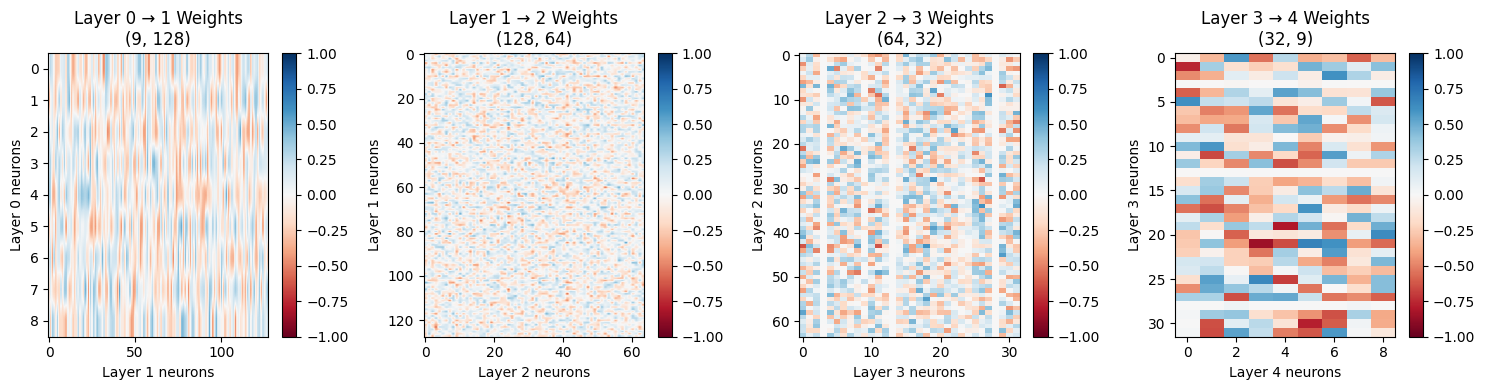

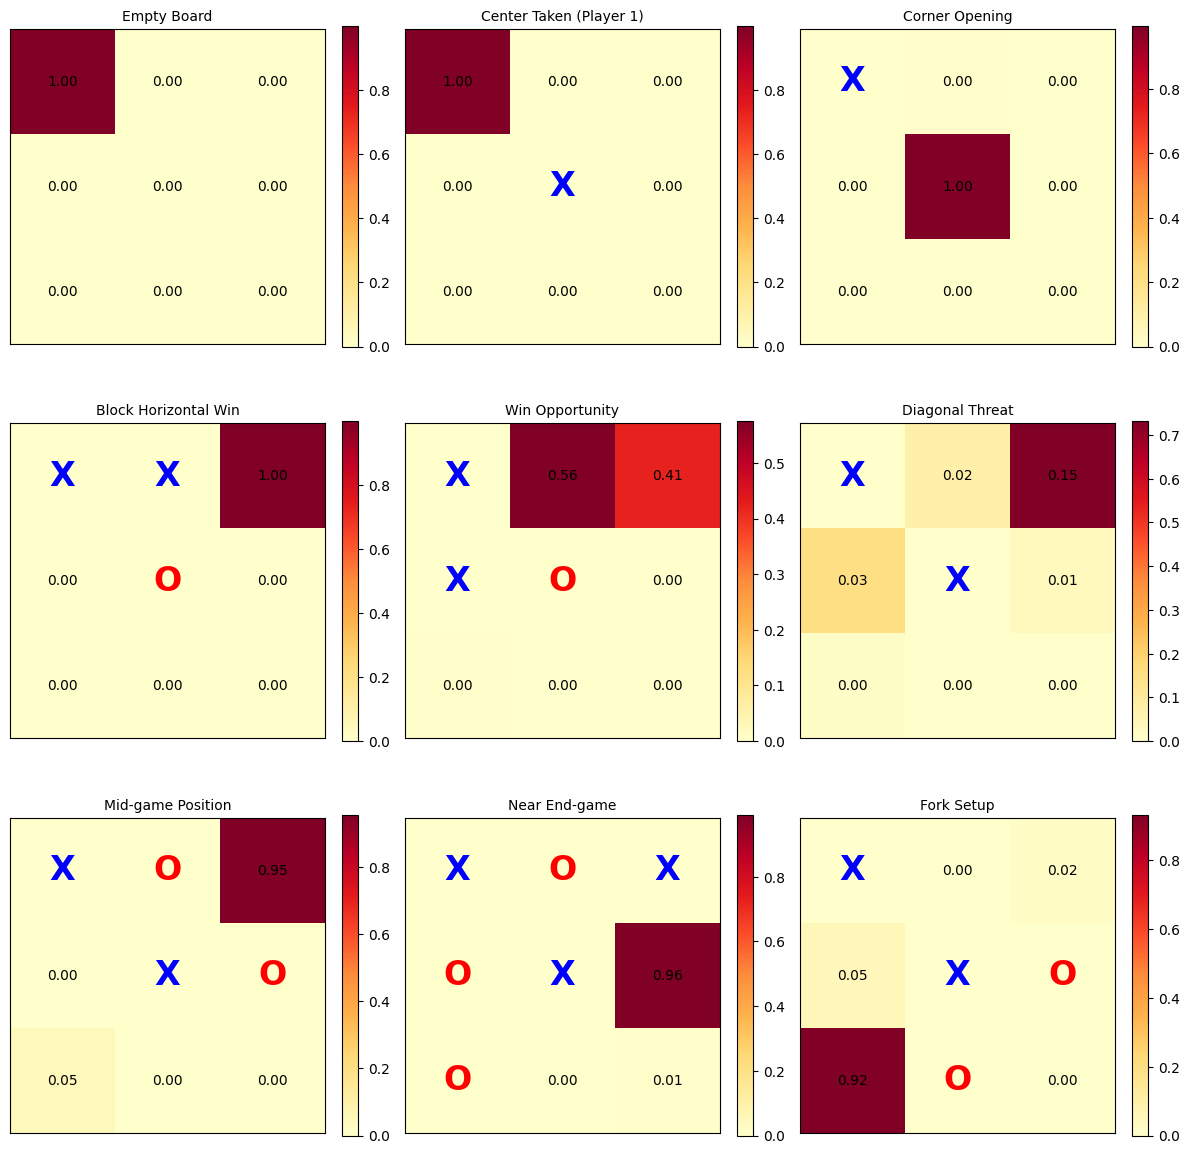

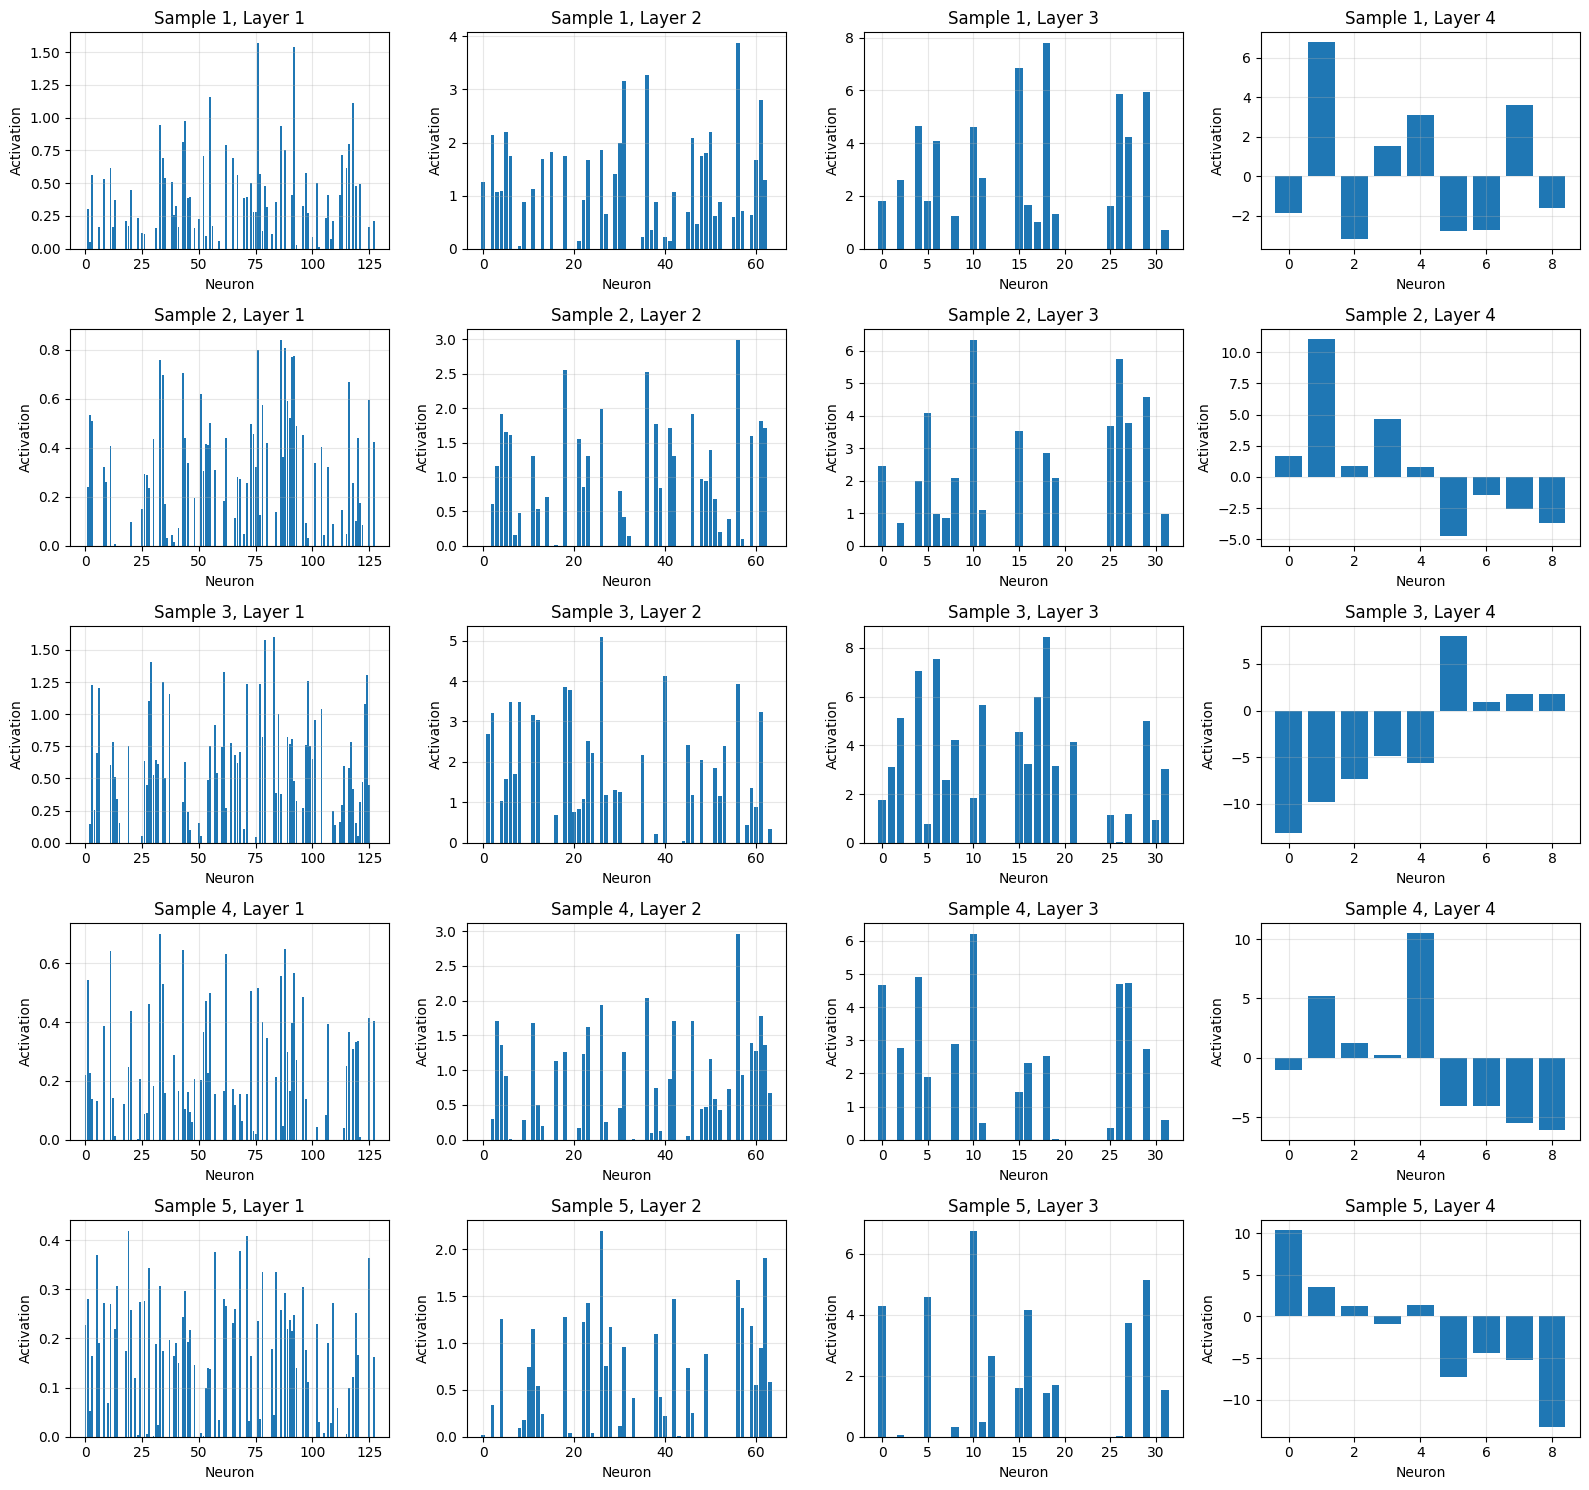

In [6]:
# Create visualizations
print("\nCreating visualizations...")
visualize_network_weights(mlp)
visualize_decision_boundaries(mlp)
visualize_activation_patterns(mlp, X_test)

print("\nAll done! Check the outputs folder for visualizations.")
